In [ ]:
import numpy as np
import time

def HS2SWE(idata, RhoNew=113.7, RhoMax=571.6, SnoTemp=-0.000, Visc=6.051e7, DQMultInc=0.1, DQMultMax=5, HsAcc=2,
           c1=2.8e-6, c2=0.042, c3=0.046, c4=0.081, c5=0.018, g=9.81, dt=86400):
    """
    Convert snow depth recordings to snow water equivalents.
    Parameters:
    - idata: 2D array of snow depth recordings (cm) where each column is a time series. 
    - for python make sure a 1 station dataset needs to be an array of 2 dimensons ((444,1) not (444,)
    - Other parameters are as defined in the code (defaults are provided).
    Returns:
    - odata: 2D array of simulated snow water equivalents (mm).
    """
    
    PAR = {'c1': c1, 'c2': c2, 'c3': c3, 'c4': c4, 'c5': c5, 'g': g, 'dt': dt}
    
    # Input data checks/preparation
    assert np.all(idata[~np.isnan(idata)] >= 0), "Negative values in input data"
    # model diagnostics on/off:
    timekeeping=1 #0 for no timetracking of runtimes, 1 for tracking
    # Initialize output data array
    odata = np.zeros_like(idata)
    
    if timekeeping:
        np.set_printoptions(threshold=np.inf)
        start = time.time()
        
    # Loop over time series of data 
    for serix in range(idata.shape[1]):   # if single station data is run, the idata arry needs to have an added dimension of length 1 in python example: data.shape=(444,1) not (444,)
        print(f"Running station: {serix + 1}")
        

        
        psdix = np.where((~np.isnan(idata[:, serix])) & (idata[:, serix] > 0))[0]
        
        if psdix.size == 0:
            continue
        
        sepix = np.concatenate(([0], np.where(np.diff(psdix) > 1)[0] + 1, [len(psdix)]))
       
        # Loop over continuous strings of non-NaN data with HS > 0
        for tsrix in range(len(sepix) - 1):
            HS = np.concatenate(([0], idata[np.arange(psdix[sepix[tsrix]],psdix[sepix[tsrix + 1]-1]+1), serix]))
           
            # Initialize data field with a zero height layer @ RhoMax
            MR = {
                'HS': np.zeros((1, len(HS))),               # layer depth matrix
                'RHO': np.ones((1, len(HS))) * RhoNew,      # layer density matrix
                'OVB': np.zeros((1, len(HS))),              # overburden mass matrix
                'AGE': np.arange(len(HS)),                  # layer age matrix
                'DIA': np.zeros((5, len(HS)))               # performance diagnostics
            }
           
            # Loop over days (tn) of period with continous snowcover 
            for tn in range(1, len(HS)):
                # Step 1: Densification of existing layer (limited by RhoMax); ATTN: any changes of the below line need to be replicated in step 3.3
                MR['RHO'][:, tn] = np.minimum(
                    MR['RHO'][:, tn - 1] + MR['RHO'][:, tn - 1] * PAR['dt'] * (
                            MR['OVB'][:, tn - 1] * PAR['g'] / (Visc * np.exp(PAR['c4'] * SnoTemp + PAR['c5'] * MR['RHO'][:, tn - 1])) +
                            PAR['c1'] * np.exp(-PAR['c2'] * SnoTemp - PAR['c3'] * np.maximum(0, MR['RHO'][:, tn - 1] - RhoNew))),
                    RhoMax)
                
                # Step 2: settling of snow according to step 1 assuming constant SWE; %ATTN: any changes of the below line need to be replicated in step 3.3
                MR['HS'][:, tn] = MR['HS'][:, tn - 1] / (MR['RHO'][:, tn] / MR['RHO'][:, tn - 1])

                # Step 3: Assimilate measured HS (add new snow / melt snow)
                # Step 3.0 if HSmeas > HSmod for first time step assume new snow fall and add layer
                if HS[tn] > np.sum(MR['HS'][:, tn]) and tn == 1:
                    nlix = MR['HS'].shape[0] + 1
                    MR['HS'] = np.vstack([MR['HS'], np.zeros((1, len(HS)))])
                    MR['HS'][nlix - 1, tn] = HS[tn] - np.sum(MR['HS'][:, tn])
                    MR['RHO'] = np.vstack([MR['RHO'], np.ones((1, len(HS))) * RhoNew])
                    MR['OVB'] = np.vstack([MR['OVB'], np.zeros((1, len(HS)))])
                    MR['AGE'] = np.vstack([MR['AGE'], np.zeros((1, len(HS)))])
                    MR['AGE'][nlix - 1, tn:] = np.arange(len(HS) - tn)

                    if HS[tn] < HS[tn - 1]:
                        MR['DIA'][0, tn] = 1 # if observed HS is decreasing while model adds new snow add a note in MR.DIA
                    
               # Step 3.1: If HSmeas > HSmod + HSacc, assume new snow fall and add layer
                elif HS[tn] > np.sum(MR['HS'][:, tn]) + HsAcc:
                    nlix = MR['HS'].shape[0] + 1
                    MR['HS'] = np.vstack([MR['HS'], np.zeros((1, len(HS)))])
                    MR['HS'][nlix - 1, tn] = HS[tn] - np.sum(MR['HS'][:, tn])
                    MR['RHO'] = np.vstack([MR['RHO'], np.ones((1, len(HS))) * RhoNew])
                    MR['OVB'] = np.vstack([MR['OVB'], np.zeros((1, len(HS)))])
                    MR['AGE'] = np.vstack([MR['AGE'], np.zeros((1, len(HS)))])
                    MR['AGE'][nlix - 1, tn:] = np.arange(len(HS) - tn)

                    if HS[tn] < HS[tn - 1]:
                        MR['DIA'][0, tn] = 1 # if observed HS is decreasing while model adds new snow add a note in MR.DIA
                    
                # Step 3.2: If HSmeas == HSmod, don't do anything
                elif HS[tn] == np.sum(MR['HS'][:, tn]):
                    MR['DIA'][1, tn] = 0 # note difference between HSmeas - HSmod if positive in MR.DIA
                    
                # Step 3.3: If HSmeas > HSmod, reapply densification with gradually decreasing densification rate until HSmeas <= HSmod
                elif HS[tn] > np.sum(MR['HS'][:, tn]):
                    MR['DIA'][1, tn] = HS[tn] - np.sum(MR['HS'][:, tn])  # note difference between HSmeas - HSmod before assimilation

                    # step 3.3.1 decreasing deinsification rate
                    DQMultCur = 1
                    while np.mean(MR['RHO'][:, tn]) < RhoMax and HS[tn] > np.sum(MR['HS'][:, tn]) and DQMultCur < DQMultMax:
                        DQMultCur += DQMultInc
                        MR['RHO'][:, tn] = np.minimum(
                            MR['RHO'][:, tn - 1] + MR['RHO'][:, tn - 1] * PAR['dt'] * (
                                    MR['OVB'][:, tn - 1] * PAR['g'] / (Visc * np.exp(PAR['c4'] * SnoTemp + PAR['c5'] * MR['RHO'][:, tn - 1])) +
                                    PAR['c1'] * np.exp(-PAR['c2'] * SnoTemp - PAR['c3'] * np.maximum(0, MR['RHO'][:, tn - 1] - RhoNew))) / DQMultCur,
                            RhoMax)
                        MR['HS'][:, tn] = MR['HS'][:, tn - 1] / (MR['RHO'][:, tn] / MR['RHO'][:, tn - 1])

                    MR['DIA'][2, tn] = HS[tn] - np.sum(MR['HS'][:, tn]) # note difference between HSmeas - HSmod after assimilation
                    MR['DIA'][3, tn] = -DQMultCur                       # note assimilation steps required to match HSmeas (negative for decreasing densification)

                    # step 3.3.2 if still HSmeas > HSmod (because of RhoMax or because of MAXITER) don't do anything
                    if HS[tn] > np.sum(MR['HS'][:, tn]):
                        # don't do anything
                        # later eventually add snow layer MR['DIA'][5, tn]
                        MR['DIA'][4, tn] = -1  # note when densification was too high to meet HS
                        
                # step 3.4 if HSmeas < HSmod reapply densification with gradually increasing densification rate until HSmeas >= HSmod or MR.RHO == RHOmax for all layers    
                elif HS[tn] < np.sum(MR['HS'][:, tn]):
                        MR['DIA'][1, tn] = HS[tn] - np.sum(MR['HS'][:, tn])  # note difference between HSmeas - HSmod before assimilation
    
                        # step 3.4.1 increase densification rate
                        DQMultCur = 1
                        while np.mean(MR['RHO'][:, tn]) < RhoMax and HS[tn] < np.sum(MR['HS'][:, tn]) and DQMultCur < DQMultMax:
                            DQMultCur += DQMultInc
                            MR['RHO'][:, tn] = np.minimum((MR['RHO'][:, tn - 1] + MR['RHO'][:, tn - 1] * PAR['dt'] * 
                                      (MR['OVB'][:, tn - 1] * PAR['g'] / (Visc * np.exp(PAR['c4'] * SnoTemp + PAR['c5'] * MR['RHO'][:, tn - 1])) +
                                       PAR['c1'] * np.exp(-PAR['c2'] * SnoTemp - PAR['c3'] * np.maximum(0, MR['RHO'][:, tn - 1] - RhoNew))) * DQMultCur), RhoMax)
                            MR['HS'][:, tn] = MR['HS'][:, tn - 1] / (MR['RHO'][:, tn] / MR['RHO'][:, tn - 1])
    
                        MR['DIA'][2, tn] = HS[tn] - np.sum(MR['HS'][:, tn])  # note difference between HSmeas - HSmod after assimilation
                        MR['DIA'][3, tn] = DQMultCur  # note assimilation steps required to match HSmeas (positive for increasing densification)
                     
                        #step 3.4.2 if still HSmeas < HSmod (because of RhoMax or MAXITER) start melting from above
                        if HS[tn] < np.sum(MR['HS'][:,tn]):
                            for lix in range(len(MR['HS']) - 1, -1, -1):

                                MR['HS'][lix, tn] = HS[tn] - np.sum(MR['HS'][:lix, tn])
                                
                                if MR['HS'][lix, tn] >= 0:
                                    break
                                else:
                                    MR['HS'][lix, tn] = 0
                            MR['DIA'][4, tn] = 1  # note when melt condition met (negative density or temperature changes)  
                else:
                    # this case should not happen
                    raise Exception("Unexpected case")
                # Step 4: Recalculate overburden
                nlix = MR['HS'].shape[0]
                MR['OVB'][nlix - 1, tn] = 0
                for nlix in range(MR['HS'].shape[0] - 2, -1, -1):
                    MR['OVB'][nlix, tn] = np.sum(MR['HS'][nlix + 1:, tn] * MR['RHO'][nlix + 1:, tn] / 100)

            SWE = np.sum(MR['HS'] * MR['RHO'] / 100, axis=0)
            
            odata[np.arange(psdix[sepix[tsrix]],psdix[sepix[tsrix + 1]-1]+1),serix]=SWE[1:]
        # timekeeping overhead
        if timekeeping:
            end_index = time.time()
            print(f"Elapsed time for Station, {serix + 1} : {end_index - start_index} s")

    # do we want a statement here
    odata[idata == 0] = 0
    
    # timekeeping overhead
    if timekeeping:
        end=time.time()
        print(f"Average time per station: {(end - start)/idata.shape[1]} s")
        
    return odata

In [45]:
# Synthetic snow depth time series [cm]
n_days = 60
days = np.arange(n_days)
HS_syn = np.zeros(n_days)

# snowfall event 1: days 10–15, linear up to 60 cm
HS_syn[10:15] = np.linspace(0, 60, 5)


# stable snowpack baseline (70 cm)
HS_syn[15:35] = 70

# --- Add sinusoidal oscillation during stable snow period ---
# amp = 1                          # amplitude in cm
# period = 20                      # period of sine wave
# t = np.arange(20)                # days 25–35
# HS_syn[15:35] += amp * np.sin(2 * np.pi * t / period)

# melting: 70 → 0
HS_syn[35:60] = np.linspace(70, 0, 25)

HS_syn

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , 15.        , 30.        , 45.        , 60.        ,
       70.        , 70.        , 70.        , 70.        , 70.        ,
       70.        , 70.        , 70.        , 70.        , 70.        ,
       70.        , 70.        , 70.        , 70.        , 70.        ,
       70.        , 70.        , 70.        , 70.        , 70.        ,
       70.        , 67.08333333, 64.16666667, 61.25      , 58.33333333,
       55.41666667, 52.5       , 49.58333333, 46.66666667, 43.75      ,
       40.83333333, 37.91666667, 35.        , 32.08333333, 29.16666667,
       26.25      , 23.33333333, 20.41666667, 17.5       , 14.58333333,
       11.66666667,  8.75      ,  5.83333333,  2.91666667,  0.        ])

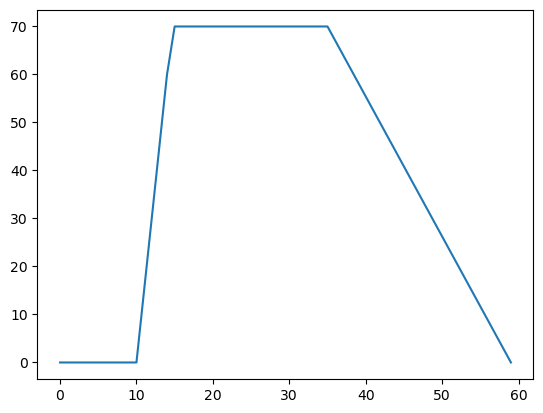

In [46]:
plt.plot(days, HS_syn, label='Snow Depth [cm]')

In [48]:
if MR is None:
    raise RuntimeError("No snow in this example.")

Tseg = MR['HS'].shape[1]
t_model = np.arange(Tseg)  # model time steps, including t=0

rho = MR['RHO']
ovb = MR['OVB']

# densification per day (Δρ)
dens_change = np.zeros_like(rho)
dens_change[:, 1:] = rho[:, 1:] - rho[:, :-1]

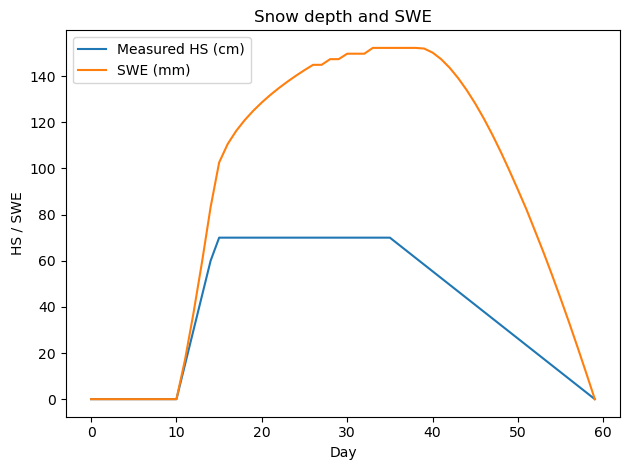

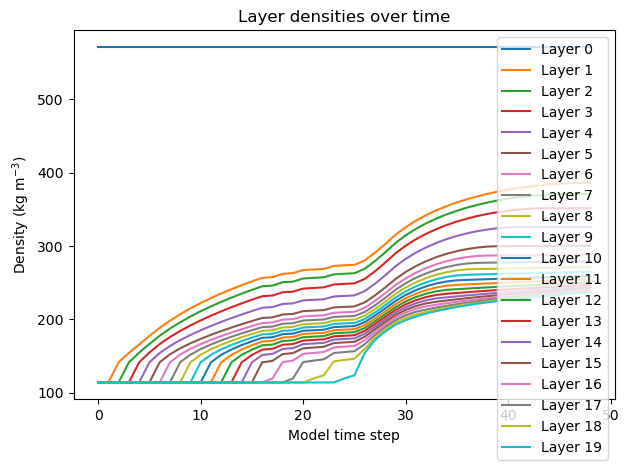

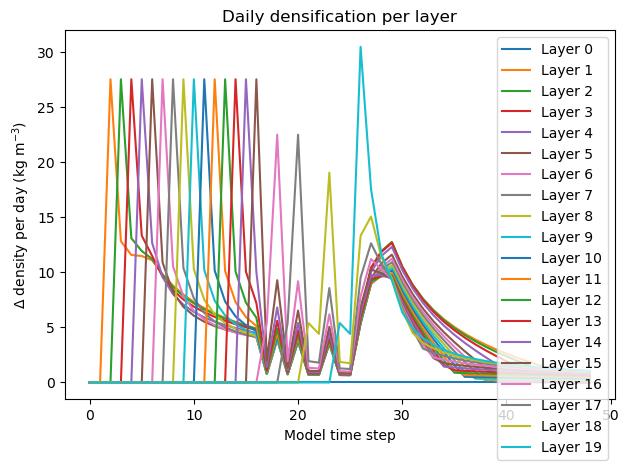

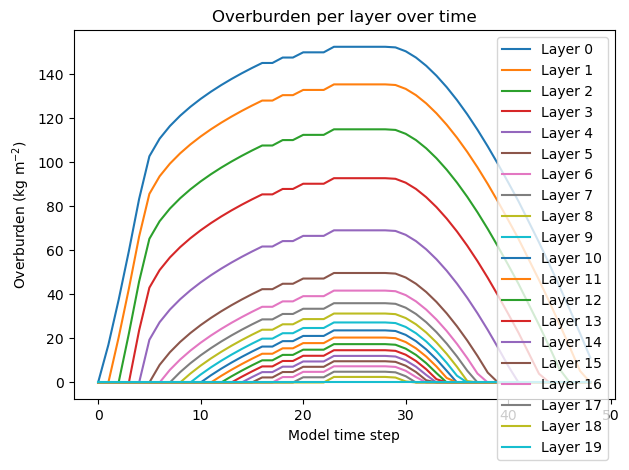

In [49]:
# 1) HS vs SWE
plt.figure()
plt.plot(days, HS_syn, label="Measured HS (cm)")
plt.plot(days, SWE, label="SWE (mm)")
plt.xlabel("Day")
plt.ylabel("HS / SWE")
plt.title("Snow depth and SWE")
plt.legend()
plt.tight_layout()

# 2) Layer densities over time
plt.figure()
for i in range(rho.shape[0]):
    plt.plot(t_model, rho[i, :], label=f"Layer {i}")
plt.xlabel("Model time step")
plt.ylabel("Density (kg m$^{-3}$)")
plt.title("Layer densities over time")
plt.legend()
plt.tight_layout()

# 3) Daily densification per layer
plt.figure()
for i in range(dens_change.shape[0]):
    plt.plot(t_model, dens_change[i, :], label=f"Layer {i}")
plt.xlabel("Model time step")
plt.ylabel("Δ density per day (kg m$^{-3}$)")
plt.title("Daily densification per layer")
plt.legend()
plt.tight_layout()

# 4) Overburden per layer over time
plt.figure()
for i in range(ovb.shape[0]):
    plt.plot(t_model, ovb[i, :], label=f"Layer {i}")
plt.xlabel("Model time step")
plt.ylabel("Overburden (kg m$^{-2}$)")
plt.title("Overburden per layer over time")
plt.legend()
plt.tight_layout()

plt.show()